In [1]:
# pip install seaborn

In [2]:
from elasticsearch import Elasticsearch
import pandas as pd
import json
from ipywidgets import interact, Dropdown
import matplotlib.pyplot as plt
import warnings
import urllib3
import time
import requests
import numpy as np
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets

# Suppress all warnings
warnings.filterwarnings("ignore")

# Suppress only InsecureRequestWarning from urllib3 (for verify_certs=False)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# === API Parameter ===
api_url = "http://localhost:9090/api/youtubelifeapi"

# === Define two ranges to avoid 10,000 limit ===
ranges = [
    {"start": "2025-03-01", "end": "2025-04-10"},
    {"start": "2025-04-11", "end": "2026-01-01"}
]

# === Fetch & Combine ===
all_data = []

for i, params in enumerate(ranges):
    response = requests.get(api_url, params=params)
    if response.status_code == 200:
        json_data = response.json()
        results = json_data.get("data", [])
        print(f"[OK] Retrieved {len(results)} documents from range {i+1}")
        all_data.append(pd.DataFrame(results))
    else:
        print(f"[X] Request {i+1} failed with status code {response.status_code}")

# === Combine & Clean ===
if all_data:
    ytl_df_raw = pd.concat(all_data, ignore_index=True)
    print(f"[✓] Combined total: {len(ytl_df_raw)} rows.")
    display(ytl_df_raw.columns)
else:
    print("[X] No data retrieved from any range.")

[OK] Retrieved 4500 documents from range 1
[OK] Retrieved 9755 documents from range 2
[✓] Combined total: 14255 rows.


Index(['snippet', 'search_prompt', 'kind', 'etag', 'id', 'contentDetails',
       'statistics'],
      dtype='object')

In [3]:

# Normalize raw data
ytl_df = pd.json_normalize(ytl_df_raw.to_dict(orient='records'))

# Ensure numeric types for relevant fields
for field in ['statistics.viewCount', 'statistics.likeCount', 'statistics.commentCount', 'statistics.favoriteCount']:
    ytl_df[field] = ytl_df[field].astype(float)

# Parse and localize datetime
ytl_df['snippet.publishedAt'] = pd.to_datetime(ytl_df['snippet.publishedAt'], utc=True)
ytl_df['published_melbourne'] = ytl_df['snippet.publishedAt'].dt.tz_convert('Australia/Melbourne')

# Calculate hours since posted using datetime difference
now = pd.Timestamp.now(tz='UTC')
ytl_df['hours_since_post'] = (now - ytl_df['snippet.publishedAt']).dt.total_seconds() / 3600

# Compute raw weighted score
ytl_df['raw_score'] = (
    ytl_df['statistics.viewCount'] * 0.5 +
    ytl_df['statistics.likeCount'] * 1.0 +
    ytl_df['statistics.commentCount'] * 1.5 +
    ytl_df['statistics.favoriteCount'] * 1.2
)

# Exponential decay (freshness factor)
ytl_df['decay'] = np.exp(-0.05 * ytl_df['hours_since_post'] / 24)

# Hotness score = raw * decay
ytl_df['score1'] = ytl_df['raw_score'] * ytl_df['decay']

# Engagement score per view
ytl_df['statistics.viewCount'] = ytl_df['statistics.viewCount'].replace(0, 1)  # Avoid div-by-zero
ytl_df['score2'] = (
    (ytl_df['statistics.likeCount'] / ytl_df['statistics.viewCount']) +
    2 * (ytl_df['statistics.commentCount'] / ytl_df['statistics.viewCount']) +
    3 * (ytl_df['statistics.favoriteCount'] / ytl_df['statistics.viewCount'])
) * 100

# Clean up invalid values
ytl_df[['score1', 'score2']] = ytl_df[['score1', 'score2']].replace([np.inf, -np.inf], np.nan).fillna(0)



# Scale to [1, 100]
def clip_and_scale(series, feature_range=(1, 100)):
    lower = series.quantile(0.05)
    upper = series.quantile(0.95)
    clipped = series.clip(lower, upper)
    scaler = MinMaxScaler(feature_range=feature_range)
    return scaler.fit_transform(clipped.values.reshape(-1, 1))

def log_clip_scale(series, feature_range=(1, 100)):
    log_vals = np.log1p(series)  # log(1 + x) 防止 log(0)
    lower = log_vals.quantile(0.05)
    upper = log_vals.quantile(0.95)
    clipped = log_vals.clip(lower, upper)
    scaler = MinMaxScaler(feature_range=feature_range)
    return scaler.fit_transform(clipped.values.reshape(-1, 1))

ytl_df['score1_scaled'] = log_clip_scale(ytl_df['score1'])
# score1_log = np.log1p(ytl_df['score1'])
# ytl_df['score1_scaled'] = scaler.fit_transform(score1_log.values.reshape(-1, 1))
ytl_df['score2_scaled'] = clip_and_scale(ytl_df['score2'])

# Optional: print info
# print("[OK] DataFrame processed. Available columns:")
# print(ytl_df.columns.tolist())
# ytl_df.head()


In [4]:
# print("score1 describe:")
# print(ytl_df['score1'].describe())
import ipywidgets as widgets
# print("\nscore1_scaled describe:")
# print(ytl_df['score1_scaled'].describe())

widgets.IntSlider()
print(ytl_df.columns.tolist())

['search_prompt', 'kind', 'etag', 'id', 'snippet.publishedAt', 'snippet.description', 'snippet.title', 'snippet.channelId', 'snippet.categoryId', 'snippet.channelTitle', 'snippet.liveBroadcastContent', 'contentDetails.duration', 'contentDetails.definition', 'contentDetails.dimension', 'statistics.likeCount', 'statistics.viewCount', 'statistics.favoriteCount', 'statistics.commentCount', 'snippet.tags', 'published_melbourne', 'hours_since_post', 'raw_score', 'decay', 'score1', 'score2', 'score1_scaled', 'score2_scaled']


In [5]:
import ipywidgets as widgets

# Get min and max dates in local (Melbourne) time
start_date_actual = ytl_df['published_melbourne'].min().date()
end_date_actual = ytl_df['published_melbourne'].max().date()

# Generate full date range list for slider
date_range = pd.date_range(start=start_date_actual, end=end_date_actual, freq='D')
date_slider = widgets.SelectionRangeSlider(
    options=[d.strftime("%Y-%m-%d") for d in date_range],
    index=(0, len(date_range) - 1),
    description='Date Range:',
    orientation='horizontal',
    layout={'width': '100%'}
)

# Frequency resolution dropdown
resolution = widgets.Dropdown(
    options=[('Hourly', 'H'), ('Every 3 Hours', '3H'), ('Daily', 'D'), ('Weekly', 'W')],
    value='H',
    description='Resolution:'
)

# Combine controls into a UI layout
ui = widgets.VBox([date_slider, resolution])

# Plotting function triggered by widget updates
def update_all_plots(date_range, freq):
    start_str, end_str = date_range
    # Localize start and end to Melbourne timezone to match the DataFrame
    start = pd.to_datetime(start_str).tz_localize("Australia/Melbourne")
    end = pd.to_datetime(end_str).tz_localize("Australia/Melbourne")


    # Filter DataFrame based on selected date range
    ytl_df_filtered = ytl_df[(ytl_df['published_melbourne'] >= start) & (ytl_df['published_melbourne'] <= end)]

    if ytl_df_filtered.empty:
        print("No data for selected range.")
        return

    # Set time column as index for resampling
    ytl_df_tmp = ytl_df_filtered.set_index('published_melbourne')

    # Resample metrics
    resampled_count = ytl_df_tmp.resample(freq).size()
    resampled_views = ytl_df_tmp['statistics.viewCount'].resample(freq).sum()
    resampled_score1 = ytl_df_tmp['score1'].resample(freq).mean()
    resampled_score2 = ytl_df_tmp['score2'].resample(freq).mean()

    # Create subplots
    fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    axs[0].plot(resampled_count.index, resampled_count.values, marker='o')
    axs[0].set_title(f'Number of Uploaded Videos ({freq} resolution)')
    axs[0].set_ylabel("Upload Count")
    axs[0].grid(True)

    axs[1].plot(resampled_views.index, resampled_views.values, marker='o', color='green')
    axs[1].set_title(f'Total View Count ({freq} resolution)')
    axs[1].set_ylabel("Total Views")
    axs[1].grid(True)

    axs[2].plot(resampled_score1.index, resampled_score1.values, marker='o', color='red')
    axs[2].set_title(f'Average Score1 Over Time ({freq} resolution)')
    axs[2].set_ylabel("Average Score1")
    axs[2].grid(True)

    axs[3].plot(resampled_score2.index, resampled_score2.values, marker='o', color='orange')
    axs[3].set_title(f'Average Score2 Over Time ({freq} resolution)')
    axs[3].set_ylabel("Average Score2")
    axs[3].grid(True)

    for ax in axs:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Connect the UI widgets to the plotting function
out_all = widgets.interactive_output(update_all_plots, {
    'date_range': date_slider,
    'freq': resolution
})

# Display the full UI and output
display(ui, out_all)


Output()

In [6]:
def update_all_plots(date_range, freq):
    # Convert strings to tz-aware datetimes
    start_str, end_str = date_range
    start = pd.to_datetime(start_str).tz_localize("Australia/Melbourne")
    end = pd.to_datetime(end_str).tz_localize("Australia/Melbourne")


    # Filter using datetime column (not index)
    ytl_df_filtered = ytl_df[(ytl_df['published_melbourne'] >= start) & (ytl_df['published_melbourne'] <= end)]

    if ytl_df_filtered.empty:
        print("No data for selected range.")
        return

    # Resample by column instead of index
    resampled_count = ytl_df_filtered.resample(freq, on='published_melbourne').size()
    resampled_views = ytl_df_filtered.resample(freq, on='published_melbourne')['statistics.viewCount'].sum()
    resampled_score1 = ytl_df_filtered.resample(freq, on='published_melbourne')['score1'].mean()
    resampled_score2 = ytl_df_filtered.resample(freq, on='published_melbourne')['score2'].mean()

    # Plotting
    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Subplot 1: Upload Count vs View Count
    ax1 = axs[0]
    ax2 = ax1.twinx()
    ax1.plot(resampled_count.index, resampled_count.values, label='Upload Count', color='blue', marker='o')
    ax2.plot(resampled_views.index, resampled_views.values, label='View Count', color='green', marker='x')
    ax1.set_ylabel("Upload Count", color='blue')
    ax2.set_ylabel("Total Views", color='green')
    ax1.set_title(f'Uploads and Views Over Time ({freq} resolution)')
    ax1.grid(True)

    # Subplot 2: Score1 vs Score2
    ax3 = axs[1]
    ax4 = ax3.twinx()
    ax3.plot(resampled_score1.index, resampled_score1.values, label='Score1', color='red', marker='o')
    ax4.plot(resampled_score2.index, resampled_score2.values, label='Score2', color='orange', marker='x')
    ax3.set_ylabel("Avg Score1", color='red')
    ax4.set_ylabel("Avg Score2", color='orange')
    ax3.set_title(f'Score1 and Score2 Over Time ({freq} resolution)')
    ax3.grid(True)

    for ax in axs:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(update_all_plots, {
    'date_range': date_slider,
    'freq': resolution
})
display(ui, out)

Output()

In [7]:
def update_all_plots(date_range, freq):
    # Convert strings to tz-aware datetimes
    start_str, end_str = date_range
    start = pd.to_datetime(start_str).tz_localize("Australia/Melbourne")
    end = pd.to_datetime(end_str).tz_localize("Australia/Melbourne")


    # Filter using datetime column (not index)
    ytl_df_filtered = ytl_df[(ytl_df['published_melbourne'] >= start) & (ytl_df['published_melbourne'] <= end)]

    if ytl_df_filtered.empty:
        print("No data for selected range.")
        return

    # Resample by column instead of index
    resampled_count = ytl_df_filtered.resample(freq, on='published_melbourne').size()
    resampled_views = ytl_df_filtered.resample(freq, on='published_melbourne')['statistics.viewCount'].sum()
    resampled_score1 = ytl_df_filtered.resample(freq, on='published_melbourne')['score1_scaled'].mean()
    resampled_score2 = ytl_df_filtered.resample(freq, on='published_melbourne')['score2_scaled'].mean()

    # Plotting
    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Subplot 1: Upload Count vs View Count
    ax1 = axs[0]
    ax2 = ax1.twinx()
    ax1.plot(resampled_count.index, resampled_count.values, label='Upload Count', color='blue', marker='o')
    ax2.plot(resampled_views.index, resampled_views.values, label='View Count', color='green', marker='x')
    ax1.set_ylabel("Upload Count", color='blue')
    ax2.set_ylabel("Total Views", color='green')
    ax1.set_title(f'Uploads and Views Over Time ({freq} resolution)')
    ax1.grid(True)

    # Subplot 2: Scaled Score1 vs Scaled Score2
    ax3 = axs[1]
    ax4 = ax3.twinx()
    ax3.plot(resampled_score1.index, resampled_score1.values, label='Score1 (scaled)', color='red', marker='o')
    ax4.plot(resampled_score2.index, resampled_score2.values, label='Score2 (scaled)', color='orange', marker='x')
    ax3.set_ylabel("Avg Score1 (scaled)", color='red')
    ax4.set_ylabel("Avg Score2 (scaled)", color='orange')
    ax3.set_title(f'Scaled Score1 and Score2 Over Time ({freq} resolution)')
    ax3.grid(True)

    for ax in axs:
        ax.tick_params(axis='x', rotation=45)

    # Add legends for both subplots
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axs[0].legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    lines3, labels3 = ax3.get_legend_handles_labels()
    lines4, labels4 = ax4.get_legend_handles_labels()
    axs[1].legend(lines3 + lines4, labels3 + labels4, loc='upper left')
    
    plt.tight_layout()
    plt.show()

# ui
out = widgets.interactive_output(update_all_plots, {
    'date_range': date_slider,
    'freq': resolution
})
display(ui, out)


Output()

In [8]:
# === Request hourly traffic aggregation data from the API ===
api_url = "http://localhost:9090/trafficaggbyhour/2025-01-01/2025-06-10"

# Send GET request to the API
response = requests.get(api_url)

# Check if the request was successful
if response.status_code == 200:
    # Extract the 'Data' field from the JSON response
    data = response.json().get('Data', [])
    
    # If data is present, convert to DataFrame and display
    if data:
        cong_df = pd.DataFrame(data)
        print(f"Total Records: {len(cong_df)}")
        display(cong_df.head(8))  # Show first 8 rows
    else:
        print("No data returned by the API.")
else:
    # Print error status code and message if request failed
    print(f"Error: {response.status_code} - {response.text}")


Total Records: 195


,avg_congestion,avg_delay,avg_density,avg_speed,timestamp
0,0.234792,12.000640,331.916542,47.711206,2025-05-04T00:00:00.000Z
1,0.333298,19.649413,278.885592,45.956990,2025-05-04T02:00:00.000Z
2,0.260299,15.169264,270.137033,47.250587,2025-05-04T04:00:00.000Z
3,0.217289,12.687940,272.926788,47.759018,2025-05-04T06:00:00.000Z
4,0.192316,5.204696,314.224226,50.285272,2025-05-04T08:00:00.000Z
5,0.193703,-0.806297,390.424760,52.836286,2025-05-04T10:00:00.000Z
6,0.203522,-6.306617,542.110779,56.105016,2025-05-04T12:00:00.000Z
7,0.333404,-9.513234,797.263180,58.149733,2025-05-04T14:00:00.000Z


In [9]:
# Ensure datetime columns are in proper format
ytl_df['published_melbourne'] = pd.to_datetime(ytl_df['published_melbourne'])
cong_df['timestamp'] = pd.to_datetime(cong_df['timestamp'])

# Convert both timestamps to naive datetime (remove timezone) for accurate merging
ytl_df['published_melbourne'] = ytl_df['published_melbourne'].dt.tz_localize(None)
cong_df['timestamp'] = cong_df['timestamp'].dt.tz_localize(None)

# Aggregate video score by 2-hour intervals
ytl_2hourly = ytl_df.set_index('published_melbourne').resample('2H')[
    ['score1_scaled', 'score2_scaled']
].mean().reset_index()


# Create a new column in congestion data to align with video data timestamps
cong_df['published_melbourne'] = cong_df['timestamp']

# Merge the two datasets on the shared timestamp
merged = pd.merge(
    ytl_2hourly,
    cong_df[['published_melbourne', 'avg_congestion', 'timestamp']],
    on='published_melbourne',
    how='inner'
)

# Display the first few merged rows
print(merged.head())

  published_melbourne  score1_scaled  score2_scaled  avg_congestion  \
0 2025-05-04 00:00:00      44.666188      22.406310        0.234792   
1 2025-05-04 02:00:00      34.754782      29.122414        0.333298   
2 2025-05-04 04:00:00      52.579162      31.325509        0.260299   
3 2025-05-04 06:00:00      49.433183      25.120064        0.217289   
4 2025-05-04 08:00:00      42.684993      17.183781        0.192316   

            timestamp  
0 2025-05-04 00:00:00  
1 2025-05-04 02:00:00  
2 2025-05-04 04:00:00  
3 2025-05-04 06:00:00  
4 2025-05-04 08:00:00  


In [10]:
from scipy.stats import pearsonr, spearmanr

# Drop rows with missing values in any relevant columns
merged_clean = merged.dropna(subset=['score1_scaled', 'score2_scaled', 'avg_congestion'])

# Score1 vs Congestion
r1, p1 = pearsonr(merged_clean['score1_scaled'], merged_clean['avg_congestion'])
r1_s, p1_s = spearmanr(merged_clean['score1_scaled'], merged_clean['avg_congestion'])

# Score2 vs Congestion
r2, p2 = pearsonr(merged_clean['score2_scaled'], merged_clean['avg_congestion'])
r2_s, p2_s = spearmanr(merged_clean['score2_scaled'], merged_clean['avg_congestion'])

# Print results
print(f"[Score1] Pearson r = {r1:.3f}, p = {p1:.4f}")
print(f"[Score1] Spearman r = {r1_s:.3f}, p = {p1_s:.4f}")
print(f"[Score2] Pearson r = {r2:.3f}, p = {p2:.4f}")
print(f"[Score2] Spearman r = {r2_s:.3f}, p = {p2_s:.4f}")

[Score1] Pearson r = 0.083, p = 0.4135
[Score1] Spearman r = 0.082, p = 0.4148
[Score2] Pearson r = -0.064, p = 0.5260
[Score2] Spearman r = 0.021, p = 0.8367


In [11]:
# Step 1: Create a clean date range slider based on merged data
start_date = merged['published_melbourne'].min().date()
end_date = merged['published_melbourne'].max().date()

date_slider_scoreplot = widgets.SelectionRangeSlider(
    options=pd.date_range(start=start_date, end=end_date, freq='D'),
    index=(0, (end_date - start_date).days),
    description='Date Range',
    layout={'width': '80%'}
)

# Step 2: Function remains unchanged
def update_score_congestion_plot(date_range):
    # Convert date range tuple to datetime objects (naive)
    start_str, end_str = date_range
    start = pd.to_datetime(start_str)
    end = pd.to_datetime(end_str)

    # Filter data within selected time range
    df_filtered = merged[
        (merged['published_melbourne'] >= start) &
        (merged['published_melbourne'] <= end)
    ].dropna(subset=['score1_scaled', 'score2_scaled', 'avg_congestion'])

    if df_filtered.empty:
        print("No data for selected range.")
        return

    # Resample to 2-hour average
    df_resampled = df_filtered.set_index('published_melbourne').resample('2H').mean().reset_index()

    # Plot
    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.plot(df_resampled['published_melbourne'], df_resampled['score1_scaled'], color='red', label='Score1 (scaled)', marker='o')
    ax1.plot(df_resampled['published_melbourne'], df_resampled['score2_scaled'], color='orange', label='Score2 (scaled)', marker='x')
    ax1.set_ylabel("Score1 / Score2 (scaled)")
    ax1.set_xlabel("Time")
    ax1.tick_params(axis='y', labelcolor='black')

    ax2 = ax1.twinx()
    ax2.plot(df_resampled['published_melbourne'], df_resampled['avg_congestion'], color='blue', label='Avg Congestion', linestyle='--')
    ax2.set_ylabel("Avg Congestion", color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')

    plt.title("Score1, Score2 vs Traffic Congestion Over Time")
    fig.autofmt_xdate()
    fig.tight_layout()
    ax1.grid(True)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.show()

# Step 3: Bind the slider
out = widgets.interactive_output(update_score_congestion_plot, {
    'date_range': date_slider_scoreplot
})

display(date_slider_scoreplot, out)


SelectionRangeSlider(description='Date Range', index=(0, 10), layout=Layout(width='80%'), options=(Timestamp('…

Output()

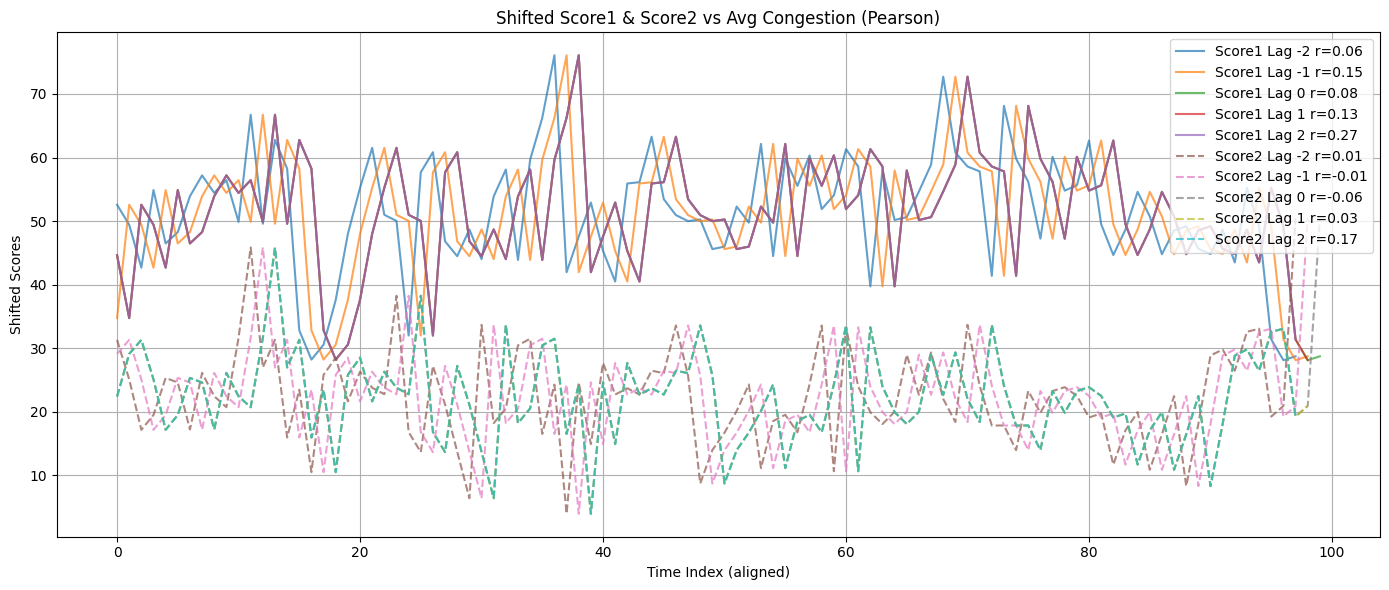


[Score1 vs Congestion] Pearson Correlations:
Lag -2: r = 0.062, p = 0.5443
Lag -1: r = 0.153, p = 0.1317
Lag  0: r = 0.083, p = 0.4135
Lag  1: r = 0.131, p = 0.1959
Lag  2: r = 0.268, p = 0.0077

[Score2 vs Congestion] Pearson Correlations:
Lag -2: r = 0.009, p = 0.9276
Lag -1: r = -0.011, p = 0.9164
Lag  0: r = -0.064, p = 0.5260
Lag  1: r = 0.031, p = 0.7577
Lag  2: r = 0.167, p = 0.1006


In [12]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

lags = [-2, -1, 0, 1, 2]

# Prepare containers
pearson_results_score1 = []
pearson_results_score2 = []

# Plot settings
plt.figure(figsize=(14, 6))

# === Score1 Lag Analysis ===
for lag in lags:
    shifted = merged_clean['score1_scaled'].shift(lag)
    valid = merged_clean[['avg_congestion']].copy()
    valid['score_shifted'] = shifted
    valid = valid.dropna()

    r, p = pearsonr(valid['score_shifted'], valid['avg_congestion'])
    pearson_results_score1.append((lag, r, p))

    plt.plot(valid['score_shifted'].values, label=f'Score1 Lag {lag} r={r:.2f}', alpha=0.7)

# === Score2 Lag Analysis ===
for lag in lags:
    shifted = merged_clean['score2_scaled'].shift(lag)
    valid = merged_clean[['avg_congestion']].copy()
    valid['score_shifted'] = shifted
    valid = valid.dropna()

    r, p = pearsonr(valid['score_shifted'], valid['avg_congestion'])
    pearson_results_score2.append((lag, r, p))

    plt.plot(valid['score_shifted'].values, linestyle='--', label=f'Score2 Lag {lag} r={r:.2f}', alpha=0.7)

# Finalize plot
plt.title("Shifted Score1 & Score2 vs Avg Congestion (Pearson)")
plt.xlabel("Time Index (aligned)")
plt.ylabel("Shifted Scores")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Print results ===
print("\n[Score1 vs Congestion] Pearson Correlations:")
for lag, r, p in pearson_results_score1:
    print(f"Lag {lag:>2}: r = {r:.3f}, p = {p:.4f}")

print("\n[Score2 vs Congestion] Pearson Correlations:")
for lag, r, p in pearson_results_score2:
    print(f"Lag {lag:>2}: r = {r:.3f}, p = {p:.4f}")


In [13]:
# Shift video score by 2 steps = 4 hours (score lags behind congestion)
merged_lag4 = merged.copy()
merged_lag4['score1_lag4'] = merged_lag4['score1_scaled'].shift(2)

# Drop missing values caused by shifting
merged_clean = merged_lag4.dropna(subset=['score1_lag4', 'avg_congestion'])

# Pearson correlation (linear)
r, p = pearsonr(merged_clean['score1_lag4'], merged_clean['avg_congestion'])
print(f"Pearson r = {r:.3f}, p = {p:.4f}")

# Spearman correlation (rank-based)
r_s, p_s = spearmanr(merged_clean['score1_lag4'], merged_clean['avg_congestion'])
print(f"Spearman r = {r_s:.3f}, p = {p_s:.4f}")

Pearson r = 0.309, p = 0.0019
Spearman r = 0.271, p = 0.0068


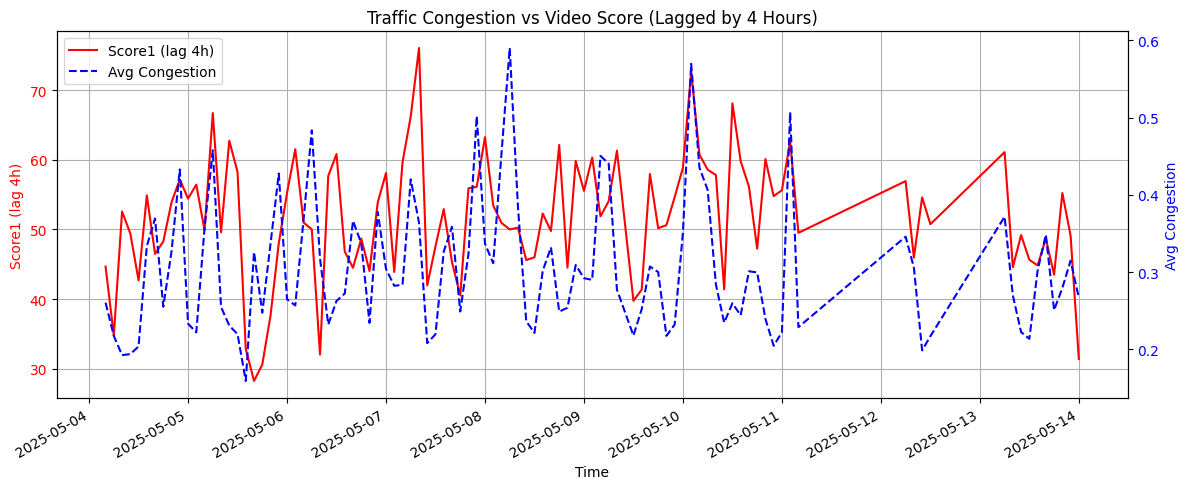

In [14]:
# === Plot Score1 (lagged 4 hours) and Avg Congestion with dual y-axes ===
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Score1 on the left y-axis
ax1.plot(merged_clean['published_melbourne'], merged_clean['score1_lag4'],
         label='Score1 (lag 4h)', color='red')
ax1.set_ylabel('Score1 (lag 4h)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# Create a second y-axis (right) to plot Avg Congestion
ax2 = ax1.twinx()
ax2.plot(merged_clean['published_melbourne'], merged_clean['avg_congestion'],
         label='Avg Congestion', color='blue', linestyle='--')
ax2.set_ylabel('Avg Congestion', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Title and axis labels
plt.title("Traffic Congestion vs Video Score (Lagged by 4 Hours)")
ax1.set_xlabel("Time")
fig.autofmt_xdate()
ax1.grid(True)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


In [15]:
# === Split the data into high and low congestion groups based on the median ===
threshold = merged_clean['avg_congestion'].median()

# Group 1: Records with congestion above the median (High Congestion)
group_high = merged_clean[merged_clean['avg_congestion'] > threshold]

# Group 2: Records with congestion at or below the median (Low Congestion)
group_low = merged_clean[merged_clean['avg_congestion'] <= threshold]

# === Print the mean Score1 (lagged 4h) for each group ===
print("Mean Score1 (lag4) after high congestion:", group_high['score1_lag4'].mean())
print("Mean Score1 (lag4) after low congestion:", group_low['score1_lag4'].mean())


Mean Score1 (lag4) after high congestion: 53.4185775718514
Mean Score1 (lag4) after low congestion: 49.90331536357275


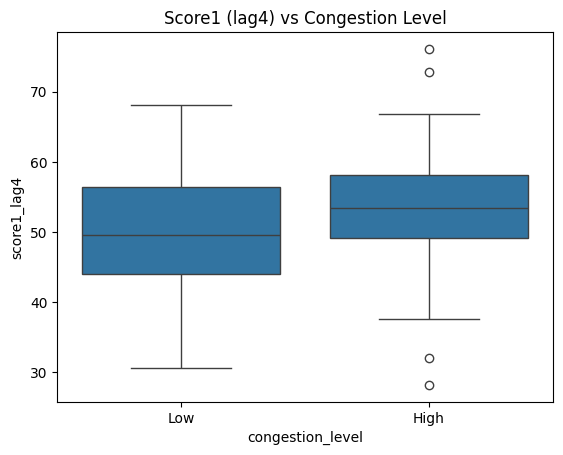

In [16]:
import seaborn as sns
merged_clean['congestion_level'] = ['High' if x > threshold else 'Low' for x in merged_clean['avg_congestion']]
sns.boxplot(data=merged_clean, x='congestion_level', y='score1_lag4')
plt.title("Score1 (lag4) vs Congestion Level")
plt.show()
